In [1]:
import os

# 1. C言語系の計算エンジンの交通整理（これは今まで通り os.environ でOK）
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import numba
numba.set_num_threads(8)

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc

import sys
sys.path.append("/workspace/omics-util/scrnaseq")
from sysvi_execution import sysvi_execution

## data prepro ##

In [3]:
def add_anot(adata, cell_annot_info):
    """
    Adding annotations

    Parameters
    ----------
    adata
        AnnData object.
    cell_annot_info
        DataFrame object. The columns must contain ['cell', 'annot'].
    --------
    """
    # cell_annot_infoに登録されている細胞のみでadataをフィルタリング
    # アノテーション情報がある細胞のみを抽出
    annotated_cells = set(cell_annot_info['cell'])
    adata_obs_cells = set(adata.obs_names)
    # 共通する細胞を特定
    common_cells = annotated_cells & adata_obs_cells

    # 共通する細胞のリストを作成（順序を保持）
    common_cells_ordered = [cell for cell in adata.obs_names if cell in common_cells]
    # adataを共通する細胞のみでフィルタリング
    adata = adata[common_cells_ordered, :].copy()

    # アノテーション情報をadataに追加
    # cell_annot_infoをインデックスでマージしやすい形に変換
    cell_annot_dict = dict(zip(cell_annot_info['cell'], cell_annot_info['annot']))
    # adata.obsにアノテーション情報を追加
    adata.obs['cell_type'] = [cell_annot_dict[cell] for cell in adata.obs_names]

    # 名前の重複対策
    adata.var_names_make_unique()
    adata.obs_names_make_unique()

    return adata

In [4]:
# qc済みデータを読み込み

file_path = "/workspace/251217_sysvi_integration/result/liver_adata_qconly_267959x30832.h5ad"
adata_liver = sc.read_h5ad(file_path)

file_path = "/workspace/251217_sysvi_integration/result/pbmc_adata_qconly_5412x14331.h5ad"
adata_pbmc = sc.read_h5ad(file_path)

In [5]:
# Annotationデータの読み込み
info_df = pd.read_csv("/workspace/data/livercellatlas_human/annot_humanAll.csv")
cell_annot_info = info_df[['cell', 'annot']]
adata_liver = add_anot(adata_liver, cell_annot_info)

In [6]:
# Annotationデータの読み込み
# 自前のAnnotation結果 (scanpyのフロー)
# 251028_new_annotation.ipynbを参照
info_df = pd.read_csv("/workspace/251011_data_integration/result/data_pbmc6k_celltypes.txt", sep="\t")
info_df.columns = ['cell', 'annot']
cell_annot_info = info_df[['cell', 'annot']]
adata_pbmc = add_anot(adata_pbmc, cell_annot_info)

In [7]:
import anndata
import pandas as pd

# --- Step 1: 各AnnDataオブジェクトから指定した細胞集団を抽出 ---
# adata_liverから抽出したい細胞タイプのリスト
liver_celltypes_to_keep = ['Fibroblasts',
                           'B cells',
                           'Neutrophils',
                           'Cholangiocytes',
                           'Hepatocytes',
                           'Macrophages'
                           ]
liver_subset = adata_liver[adata_liver.obs['cell_type'].isin(liver_celltypes_to_keep), :]

# adata_pbmcから抽出したい細胞タイプのリスト
pbmc_celltypes_to_keep = ['Dendritic', 
                          'CD4Tcells',
                          'CD8Tcells', 
                          'other', 
                          'Bcells', 
                          'Monocytes'
                          ]
pbmc_subset = adata_pbmc[adata_pbmc.obs['cell_type'].isin(pbmc_celltypes_to_keep), :]


# --- Step 2: 抽出した2つのサブセットを1つに統合 ---

# 統合したいAnnDataオブジェクトを辞書にまとめる
adatas_to_merge = {
    'liver': liver_subset,
    'pbmc': pbmc_subset
}

# 余計な -liver, -pbmc が付くことを防ぐ
# obs の共通列を揃える
common_obs_cols = list(set.intersection(*[set(a.obs.columns) for a in adatas_to_merge.values()]))
for k in adatas_to_merge:
    adatas_to_merge[k].obs = adatas_to_merge[k].obs.loc[:, common_obs_cols]

In [8]:
# .concatenate() を使って統合
# batch_keyで細胞の由来（どのadataから来たか）を記録する
combined_adata = anndata.AnnData.concatenate(
    *adatas_to_merge.values(),
    batch_key='origin',  # 由来情報を示す新しい列名
    batch_categories=adatas_to_merge.keys(), # 各サンプルの名前
    join='outer' # 消える遺伝子多数のためouterで結合
)

/tmp/ipykernel_2672320/1368749159.py:3: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = anndata.AnnData.concatenate(


In [9]:
# varの共通列を揃える
common_var_cols = list(set.intersection(*[set(a.var.columns) for a in adatas_to_merge.values()]))
for col in common_var_cols:
    combined_adata.var[col] = combined_adata.var[col+'-liver'].fillna(combined_adata.var[col+'-pbmc'])
    combined_adata.var.drop(columns=[col+'-liver', col+'-pbmc'], inplace=True)
# '-liver'で終わる列を.drop()で削除する
cols_to_drop = [col for col in combined_adata.var.columns if col.endswith('-liver')]
combined_adata.var.drop(columns=cols_to_drop, inplace=True)
# 1. '-liver'で終わる列の名前をリストとして取得
cols_to_drop = [col for col in combined_adata.var.columns if col.endswith('-liver')]
# 2. 特定した列を.drop()で削除する
combined_adata.var.drop(columns=cols_to_drop, inplace=True)

# cell_typeの表記ゆれを解消
combined_adata.obs['cell_type'] = combined_adata.obs['cell_type'].replace({
    'Bcells': 'B cells',
})

/tmp/ipykernel_2672320/1385217886.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_adata.var[col] = combined_adata.var[col+'-liver'].fillna(combined_adata.var[col+'-pbmc'])
/tmp/ipykernel_2672320/1385217886.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_adata.var[col] = combined_adata.var[col+'-liver'].fillna(combined_adata.var[col+'-pbmc'])
/tmp/ipykernel_2672320/1385217886.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects

In [10]:
# medianだとデータごとにスケールがずれるのでtarget_sumを指定
# 今回は統合後のため本来であれば指定はなくても可
sc.pp.normalize_total(combined_adata, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(combined_adata)

normalizing counts per cell
    finished (0:00:00)


In [11]:
# 1. 変動遺伝子を選択 (batch_keyを指定するのがポイント)
sc.pp.highly_variable_genes(combined_adata, batch_key='origin')

# 2. 変動遺伝子だけでデータをサブセット化
adata_pseudo = combined_adata[:, combined_adata.var.highly_variable].copy()

# 3. データをスケール
sc.pp.scale(adata_pseudo, max_value=10)

# 4. PCAを実行
sc.pp.pca(adata_pseudo, n_comps=50)

# 5. 近傍グラフを計算
sc.pp.neighbors(adata_pseudo, n_pcs=30)

# 6. UMAPを計算
sc.tl.umap(adata_pseudo)

extracting highly variable genes
    finished (0:00:01)


/root/.pyenv/versions/3.11.4/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:36)
computing neighbors
    using 'X_pca' with n_pcs = 30


2026-05-29 17:19:57.374666: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-29 17:19:57.397881: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-29 17:19:58.565290: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


    finished (0:00:27)
computing UMAP
    finished (0:00:15)


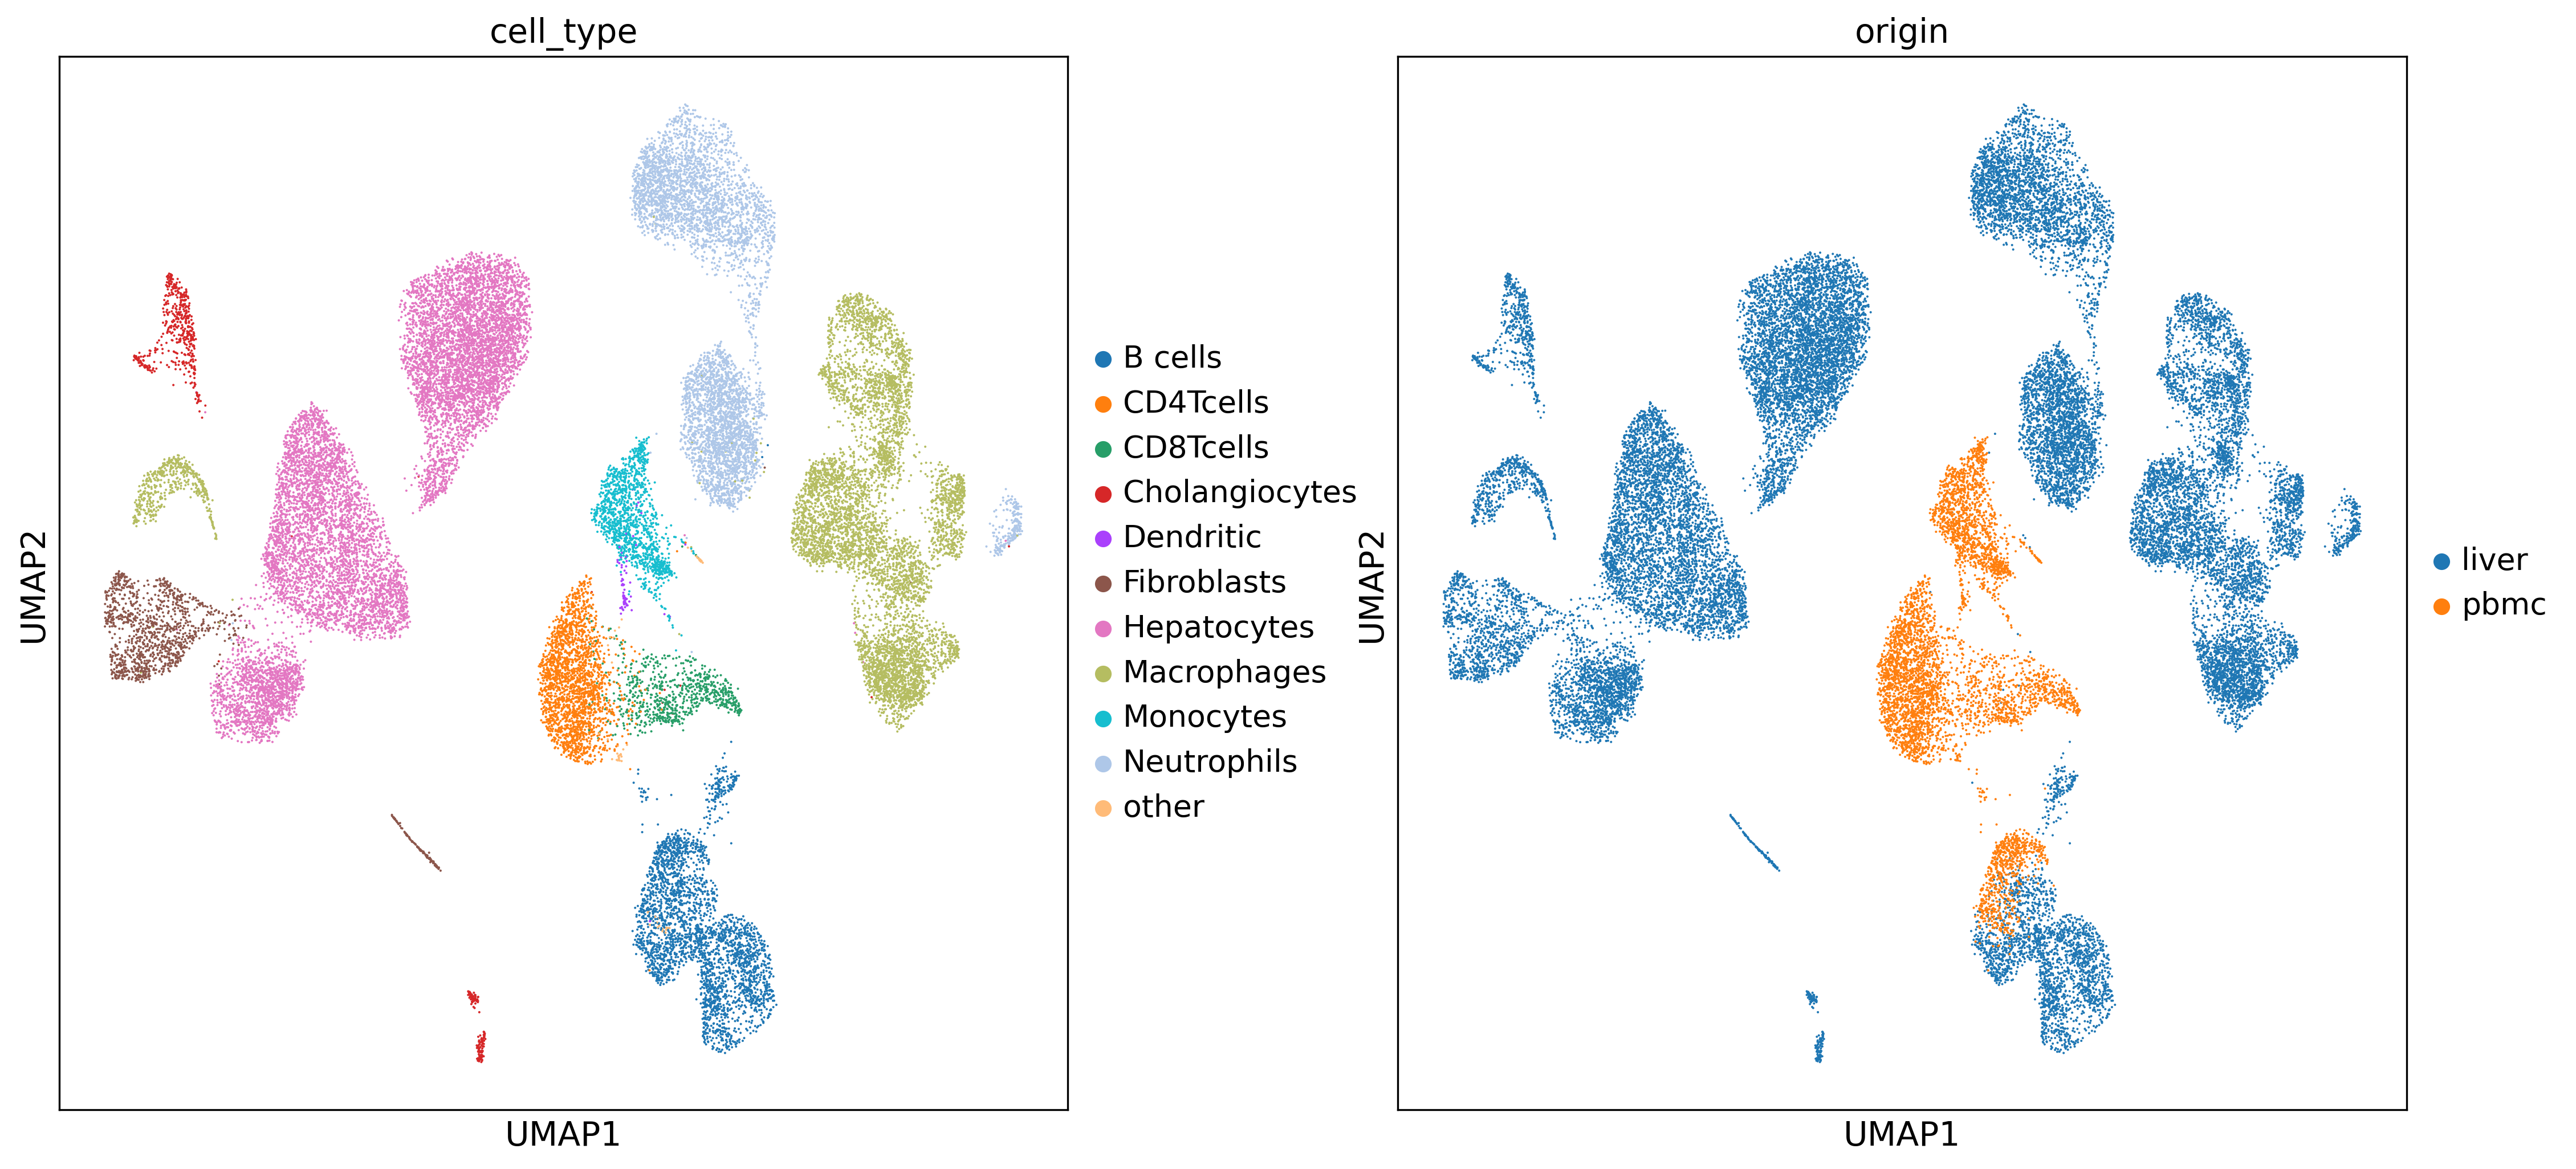

In [12]:
sc.pl.umap(adata_pseudo, color=['cell_type', 'origin'], show=False)
plt.gcf().set_size_inches(18, 8)
plt.show()

In [13]:
# 3. 高分散遺伝子（HVG）の抽出
# 全遺伝子で学習すると重すぎる＆ノイズが入るため、通常は上位2000-4000遺伝子に絞ります
sc.pp.highly_variable_genes(
    combined_adata,
    n_top_genes=3000,
    batch_key="origin", # バッチごとに分散を見て選ぶ
    subset=True         # 学習用にサブセット化
)

extracting highly variable genes
    finished (0:00:01)


In [14]:
import torch
torch.cuda.empty_cache() # 一旦軽くする

In [15]:
import json
import torch

for r_w in [2.0]:
        for c_w in [5]:
                plan_kwargs = {
                        "reconstruction_weight": r_w, 
                        "kl_weight": 1.0, # さわっても変更できないので他の値で調整
                        "z_distance_cycle_weight": c_w 
                        }
                # ディレクトリを作成
                dir_name = f"reconstruction_{r_w}_cycle_{c_w}"
                save_path_root = os.path.join("/workspace/260505_reconstruction/250529/", dir_name)
                os.makedirs(save_path_root, exist_ok=True)

                # ハイパラを保存しておく
                param_save_path = os.path.join(save_path_root, "train_plan_kwargs.json")
                with open(param_save_path, "w", encoding="utf-8") as f:
                        json.dump(plan_kwargs, f, indent=4, ensure_ascii=False)

                # 実行
                current_adata = combined_adata.copy() # 元データから毎回データを生成
                sysvi_execution(current_adata, 
                                n_top_genes=3000, 
                                batch_key="origin",
                                plan_kwargs=plan_kwargs,
                                target_batch_name="liver", 
                                save_path_root=save_path_root,
                                save_adata="260529.h5ad"
                                )
                
                torch.cuda.empty_cache()

extracting highly variable genes


`n_top_genes` > `adata.n_var`, returning all genes.
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
INFO     The model has been initialized                                                                            


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/250102_test_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoad

Training:   0%|          | 0/300 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


computing neighbors
    using data matrix X directly
    finished (0:00:02)
computing UMAP
    finished (0:00:09)


Decoding in mini-batches:   0%|          | 0/32 [00:00<?, ?it/s]/workspace/omics-util/scrnaseq/sysvi_execution.py:170: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  rb_indices = torch.from_numpy(real_batch_codes[start:end]).long().to(device).unsqueeze(1)
Decoding in mini-batches: 100%|██████████| 32/32 [00:00<00:00, 44.71it/s]


computing PCA
    with n_comps=50
    finished (0:00:09)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:02)
computing UMAP
    finished (0:00:22)
